# 05 — Damage Modelling

## Main question

**How accurately can the project estimate reported aircraft-damage probability for a defined wildlife-strike scenario?**

This notebook models `INDICATED_DAMAGE` as the primary binary target. Every probability is conditional on a wildlife strike having already been reported. The model does **not** estimate the probability that a strike will occur.

### Modelling decisions carried forward from Notebook 02

- Use the locked chronological periods:
  - training: 1990–2018,
  - validation: 2019–2021,
  - final test: 2022–2024.
- Protect the final test period from fitting, tuning, threshold selection, and model selection.
- Use only the canonical feature lists approved in Notebook 02.
- Compare a geographic model using `STATE` and `FAAREGION` with an airport-aware model that additionally uses `AIRPORT_ID`.
- Treat `NUM_STRUCK` as an ordered category rather than an exact count.
- Compare a majority baseline, logistic regression, Random Forest, and XGBoost.
- Use PR-AUC as the main discrimination metric because reported damage is uncommon, while also reporting ROC-AUC, precision, recall, F1, F2, Brier score, log loss, and confusion matrices.
- Select the main operating threshold by validation F1. Also report F2 and 70%/80% recall operating points as sensitivity analyses.
- Preserve model probabilities for calibration in Notebook 06.

The notebook exports a readable pre-model dataset and a transformed model-input sample with no missing values. The transformed sample is for demonstration; learned preprocessing remains inside each fitted pipeline.

## 1. Environment and reproducibility

`xgboost` is installed explicitly because it is not part of the Python standard library or scikit-learn. The command is safe to rerun in Jupyter environments.

In [1]:
%pip install -q xgboost

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from pathlib import Path
import json
import sys
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterGrid, TimeSeriesSplit
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_score, recall_score,
    f1_score, fbeta_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, precision_recall_curve, brier_score_loss, log_loss
)

from xgboost import XGBClassifier

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 150)

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings("ignore", category=FutureWarning)

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)

Python: 3.12.9
pandas: 2.2.3


## 2. Portable paths

The notebook searches upward from the current working directory. It also accepts the uploaded filenames used during review, which makes the notebook easier to test outside the final repository structure.

In [ ]:
ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "data").exists() or (candidate / "faa_strikes_binary_model.csv").exists():
        ROOT = candidate
        break

PROCESSED_DIR = ROOT / "data" / "processed"
OUTPUT_DIR = ROOT / "outputs" / "05_damage_modelling"
MODEL_DIR = ROOT / "models" / "candidates"
DOCS_DIR = ROOT / "docs"

for directory in [PROCESSED_DIR, OUTPUT_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

binary_candidates = [
    PROCESSED_DIR / "faa_strikes_binary_model.csv",
    ROOT / "faa_strikes_binary_model.csv",
    Path("/mnt/data/faa_strikes_binary_model(1).csv"),
]

feature_candidates = [
    DOCS_DIR / "feature_lists.json",
    ROOT / "feature_lists.json",
]

BINARY_PATH = next((p for p in binary_candidates if p.exists()), None)
FEATURE_LIST_PATH = next((p for p in feature_candidates if p.exists()), None)

if BINARY_PATH is None:
    raise FileNotFoundError(
        "faa_strikes_binary_model.csv was not found. Run Notebook 02 first "
        "or place its export in data/processed/."
    )

print("Repository root:", ROOT)
print("Binary dataset:", BINARY_PATH)
print("Feature-list artifact:", FEATURE_LIST_PATH or "not found; verified fallback will be used")

Repository root: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis
Binary dataset: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\data\processed\faa_strikes_binary_model.csv
Feature-list artifact: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\docs\feature_lists.json


## 3. Load and verify the restricted modelling dataset

The binary file is a **pre-model dataset**, not the final numerical matrix. It may retain missing numerical values because imputation must be learned from the training period inside each pipeline.

The checks below demonstrate its dimensions, memory use, temporal coverage, target prevalence, and missingness.

In [4]:
df = pd.read_csv(BINARY_PATH, low_memory=False)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Approximate memory: {df.memory_usage(deep=True).sum() / 1024**2:,.1f} MB")
display(df.head())
display(df.info())

Rows: 319,107
Columns: 25
Approximate memory: 293.2 MB


,INDICATED_DAMAGE,SEASON,MONTH_SIN,MONTH_COS,WILDLIFE_TYPE,SIZE,NUM_STRUCK,AC_CLASS,AC_MASS_GROUP,TYPE_ENG,NUM_ENGS,WARNED,PHASE_OF_FLIGHT,HEIGHT,SPEED,TIME_OF_DAY,SKY,PRECIPITATION,STATE,FAAREGION,AIRPORT_ID,TEMPORAL_SPLIT,TARGET_CONFLICT_FLAG,INCIDENT_YEAR,INDEX_NR
0,0,Summer,1.224647e-16,-1.000000,Bird,Medium,1,A,Heavy,D,2.0,Unknown,Take-off Run,0.0,NaN,Not reported,Not reported,Not reported,CA,AWP,KSMF,train_1990_2018,0,1996,608242
1,0,Summer,1.224647e-16,-1.000000,Bird,Medium,1,A,Heavy,D,2.0,Unknown,Take-off Run,0.0,NaN,Not reported,Not reported,Not reported,CO,ANM,KDEN,train_1990_2018,0,1996,608243
2,0,Summer,-5.000000e-01,-0.866025,Bird,Medium,1,A,Heavy,D,2.0,Unknown,Take-off Run,0.0,NaN,Not reported,Not reported,Not reported,NE,ACE,KOMA,train_1990_2018,0,1996,608244
3,0,Summer,-5.000000e-01,-0.866025,Bird,Medium,1,A,Heavy,D,2.0,Unknown,Approach,1000.0,NaN,Not reported,Not reported,Not reported,DC,AEA,KIAD,train_1990_2018,0,1996,608245
4,1,Summer,-5.000000e-01,-0.866025,Bird,Medium,1,A,Heavy,D,2.0,Unknown,Climb,5000.0,NaN,Not reported,Not reported,Not reported,NY,AEA,KLGA,train_1990_2018,0,1996,608246


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319107 entries, 0 to 319106
Data columns (total 25 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   INDICATED_DAMAGE      319107 non-null  int64  
 1   SEASON                319107 non-null  object 
 2   MONTH_SIN             319107 non-null  float64
 3   MONTH_COS             319107 non-null  float64
 4   WILDLIFE_TYPE         319107 non-null  object 
 5   SIZE                  319107 non-null  object 
 6   NUM_STRUCK            319107 non-null  object 
 7   AC_CLASS              319107 non-null  object 
 8   AC_MASS_GROUP         319107 non-null  object 
 9   TYPE_ENG              319107 non-null  object 
 10  NUM_ENGS              227893 non-null  float64
 11  WARNED                319107 non-null  object 
 12  PHASE_OF_FLIGHT       319107 non-null  object 
 13  HEIGHT                160917 non-null  float64
 14  SPEED                 100786 non-null  float64
 15  

None

In [5]:
required_columns = {
    "INDICATED_DAMAGE", "TEMPORAL_SPLIT", "INCIDENT_YEAR",
    "INDEX_NR", "TARGET_CONFLICT_FLAG"
}
missing_required = sorted(required_columns - set(df.columns))
assert not missing_required, f"Missing required columns: {missing_required}"

assert set(df["INDICATED_DAMAGE"].dropna().unique()).issubset({0, 1})
assert df["INDICATED_DAMAGE"].notna().all()
assert df["INDEX_NR"].is_unique, "INDEX_NR should identify one retained incident."

split_summary = (
    df.groupby("TEMPORAL_SPLIT")
      .agg(
          rows=("INDEX_NR", "size"),
          first_year=("INCIDENT_YEAR", "min"),
          last_year=("INCIDENT_YEAR", "max"),
          damaged=("INDICATED_DAMAGE", "sum"),
          damage_rate=("INDICATED_DAMAGE", "mean"),
      )
      .reset_index()
)
split_summary["damage_rate_pct"] = 100 * split_summary["damage_rate"]
display(split_summary.round(3))

missing_summary = (
    df.isna().mean().mul(100)
      .rename("missing_pct")
      .to_frame()
      .query("missing_pct > 0")
      .sort_values("missing_pct", ascending=False)
)
display(missing_summary.round(2))

,TEMPORAL_SPLIT,rows,first_year,last_year,damaged,damage_rate,damage_rate_pct
0,test_2022_2024,59219,2022,2024,2246,0.038,3.793
1,train_1990_2018,215274,1990,2018,16737,0.078,7.775
2,validation_2019_2021,44614,2019,2021,1925,0.043,4.315


,missing_pct
SPEED,68.42
HEIGHT,49.57
NUM_ENGS,28.58


### Interpretation

A lower damage rate in later periods is evidence of temporal distribution shift. It may reflect changes in strike circumstances, aircraft fleets, reporting practice, or data completeness. The chronological design therefore provides a more demanding and relevant assessment than a random split.

Missing values in `HEIGHT`, `SPEED`, or `NUM_ENGS` do not mean that Notebook 02 failed. They remain visible so that their imputation statistics are estimated only from training records.

## 4. Canonical feature lists and leakage assertion

Notebook 02 remains the source of truth. When its JSON artifact is available, this notebook loads it directly. The fallback lists reproduce the approved definitions and are checked against the dataset.

`INCIDENT_YEAR`, `TEMPORAL_SPLIT`, `INDEX_NR`, and `TARGET_CONFLICT_FLAG` are retained for validation or audit purposes but are not predictors.

In [6]:
fallback_feature_lists = {
    "core_features": [
        "SEASON", "MONTH_SIN", "MONTH_COS", "WILDLIFE_TYPE", "SIZE",
        "NUM_STRUCK", "AC_CLASS", "AC_MASS_GROUP", "TYPE_ENG",
        "NUM_ENGS", "WARNED"
    ],
    "extended_features": [
        "SEASON", "MONTH_SIN", "MONTH_COS", "WILDLIFE_TYPE", "SIZE",
        "NUM_STRUCK", "AC_CLASS", "AC_MASS_GROUP", "TYPE_ENG",
        "NUM_ENGS", "WARNED", "PHASE_OF_FLIGHT", "HEIGHT", "SPEED",
        "TIME_OF_DAY", "SKY", "PRECIPITATION", "STATE", "FAAREGION"
    ],
    "airport_aware_features": [
        "SEASON", "MONTH_SIN", "MONTH_COS", "WILDLIFE_TYPE", "SIZE",
        "NUM_STRUCK", "AC_CLASS", "AC_MASS_GROUP", "TYPE_ENG",
        "NUM_ENGS", "WARNED", "PHASE_OF_FLIGHT", "HEIGHT", "SPEED",
        "TIME_OF_DAY", "SKY", "PRECIPITATION", "STATE", "FAAREGION",
        "AIRPORT_ID"
    ],
    "primary_target": "INDICATED_DAMAGE",
    "seed": SEED,
}

if FEATURE_LIST_PATH is not None:
    with open(FEATURE_LIST_PATH, "r", encoding="utf-8") as f:
        feature_lists = json.load(f)
else:
    feature_lists = fallback_feature_lists.copy()
    warnings.warn(
        "feature_lists.json was not found. The approved Notebook 02 fallback "
        "is being used. Regenerate the JSON artifact before final submission."
    )

TARGET = feature_lists.get("primary_target", "INDICATED_DAMAGE")
CORE_FEATURES = [c for c in feature_lists["core_features"] if c in df.columns]
EXTENDED_FEATURES = [c for c in feature_lists["extended_features"] if c in df.columns]
AIRPORT_AWARE_FEATURES = [
    c for c in feature_lists["airport_aware_features"] if c in df.columns
]

feature_set_table = pd.DataFrame({
    "feature_set": ["core", "extended_geographic", "airport_aware"],
    "feature_count": [
        len(CORE_FEATURES), len(EXTENDED_FEATURES), len(AIRPORT_AWARE_FEATURES)
    ],
    "includes_state": [
        "STATE" in CORE_FEATURES, "STATE" in EXTENDED_FEATURES,
        "STATE" in AIRPORT_AWARE_FEATURES
    ],
    "includes_region": [
        "FAAREGION" in CORE_FEATURES, "FAAREGION" in EXTENDED_FEATURES,
        "FAAREGION" in AIRPORT_AWARE_FEATURES
    ],
    "includes_airport_id": [
        "AIRPORT_ID" in CORE_FEATURES, "AIRPORT_ID" in EXTENDED_FEATURES,
        "AIRPORT_ID" in AIRPORT_AWARE_FEATURES
    ],
})
display(feature_set_table)

assert set(EXTENDED_FEATURES).issubset(AIRPORT_AWARE_FEATURES)
assert "AIRPORT_ID" not in EXTENDED_FEATURES
assert "AIRPORT_ID" in AIRPORT_AWARE_FEATURES

,feature_set,feature_count,includes_state,includes_region,includes_airport_id
0,core,11,False,False,False
1,extended_geographic,19,True,True,False
2,airport_aware,20,True,True,True


In [7]:
forbidden_predictors = {
    "DAMAGE_LEVEL", "EFFECT", "EFFECT_OTHER", "AOS",
    "COST_REPAIRS", "COST_OTHER", "COST_REPAIRS_INFL_ADJ",
    "COST_OTHER_INFL_ADJ", "NR_INJURIES", "NR_FATALITIES",
    "INCIDENT_YEAR", "TEMPORAL_SPLIT", "INDEX_NR", "TARGET_CONFLICT_FLAG"
}
forbidden_predictors |= {
    c for c in df.columns if c.startswith(("DAM_", "STR_", "ING_"))
}

for set_name, features in {
    "core": CORE_FEATURES,
    "extended": EXTENDED_FEATURES,
    "airport_aware": AIRPORT_AWARE_FEATURES,
}.items():
    leaked = sorted(set(features) & forbidden_predictors)
    assert not leaked, f"{set_name} contains forbidden predictors: {leaked}"

print("Leakage assertions passed.")

Leakage assertions passed.


## 5. Demonstration export: readable pre-model dataset

This output is the cleaned, human-readable table that individuals can inspect. It includes the target, all approved airport-aware predictors, split metadata, and identifiers. It is not falsely presented as an already imputed matrix.

In [8]:
PREMODEL_COLUMNS = list(dict.fromkeys(
    [TARGET] + AIRPORT_AWARE_FEATURES +
    ["TEMPORAL_SPLIT", "INCIDENT_YEAR", "INDEX_NR", "TARGET_CONFLICT_FLAG"]
))

premodel_df = df[PREMODEL_COLUMNS].copy()
premodel_path = PROCESSED_DIR / "faa_strikes_binary_model_ready.csv"
premodel_df.to_csv(premodel_path, index=False)

premodel_info = pd.DataFrame([{
    "file": premodel_path.name,
    "rows": premodel_df.shape[0],
    "columns": premodel_df.shape[1],
    "file_size_mb": premodel_path.stat().st_size / 1024**2,
    "cells_missing": int(premodel_df.isna().sum().sum()),
    "purpose": "Readable cleaned dataset before learned preprocessing"
}])
display(premodel_info.round(2))
display(premodel_df.head())

,file,rows,columns,file_size_mb,cells_missing,purpose
0,faa_strikes_binary_model_ready.csv,319107,25,55.84,467725,Readable cleaned dataset before learned prepro...


,INDICATED_DAMAGE,SEASON,MONTH_SIN,MONTH_COS,WILDLIFE_TYPE,SIZE,NUM_STRUCK,AC_CLASS,AC_MASS_GROUP,TYPE_ENG,NUM_ENGS,WARNED,PHASE_OF_FLIGHT,HEIGHT,SPEED,TIME_OF_DAY,SKY,PRECIPITATION,STATE,FAAREGION,AIRPORT_ID,TEMPORAL_SPLIT,INCIDENT_YEAR,INDEX_NR,TARGET_CONFLICT_FLAG
0,0,Summer,1.224647e-16,-1.000000,Bird,Medium,1,A,Heavy,D,2.0,Unknown,Take-off Run,0.0,NaN,Not reported,Not reported,Not reported,CA,AWP,KSMF,train_1990_2018,1996,608242,0
1,0,Summer,1.224647e-16,-1.000000,Bird,Medium,1,A,Heavy,D,2.0,Unknown,Take-off Run,0.0,NaN,Not reported,Not reported,Not reported,CO,ANM,KDEN,train_1990_2018,1996,608243,0
2,0,Summer,-5.000000e-01,-0.866025,Bird,Medium,1,A,Heavy,D,2.0,Unknown,Take-off Run,0.0,NaN,Not reported,Not reported,Not reported,NE,ACE,KOMA,train_1990_2018,1996,608244,0
3,0,Summer,-5.000000e-01,-0.866025,Bird,Medium,1,A,Heavy,D,2.0,Unknown,Approach,1000.0,NaN,Not reported,Not reported,Not reported,DC,AEA,KIAD,train_1990_2018,1996,608245,0
4,1,Summer,-5.000000e-01,-0.866025,Bird,Medium,1,A,Heavy,D,2.0,Unknown,Climb,5000.0,NaN,Not reported,Not reported,Not reported,NY,AEA,KLGA,train_1990_2018,1996,608246,0


## 6. Locked chronological partitions

The project retains the chronological periods established in Notebook 02:

- training: 1990–2018,
- validation: 2019–2021,
- locked final test: 2022–2024.

Hyperparameter selection is performed only within the 1990–2018 training
period. Rather than using a single development/tuning split, chronological
cross-validation is used so that each fold trains on earlier observations and
evaluates on later observations.

The 2019–2021 validation period is not used for hyperparameter selection.
The 2022–2024 final test period remains completely untouched in this notebook.

In [ ]:
train_mask = df["TEMPORAL_SPLIT"].eq("train_1990_2018")
validation_mask = df["TEMPORAL_SPLIT"].eq("validation_2019_2021")
test_mask = df["TEMPORAL_SPLIT"].eq("test_2022_2024")


y_train = df.loc[train_mask, TARGET].astype(int)
y_validation = df.loc[validation_mask, TARGET].astype(int)
y_test_locked = df.loc[test_mask, TARGET].astype(int)

partition_table = pd.DataFrame([
    [
        "training_for_chronological_cv",
        int(train_mask.sum()),
        1990,
        2018,
        df.loc[train_mask, TARGET].mean()
    ],
    [
        "official_validation",
        int(validation_mask.sum()),
        2019,
        2021,
        df.loc[validation_mask, TARGET].mean()
    ],
    [
        "locked_final_test",
        int(test_mask.sum()),
        2022,
        2024,
        df.loc[test_mask, TARGET].mean()
    ],
], columns=[
    "partition",
    "rows",
    "first_year",
    "last_year",
    "damage_rate"
])

partition_table["damage_rate_pct"] = (
    100 * partition_table["damage_rate"]
)

display(partition_table.round(3))

assert not (train_mask & validation_mask).any()
assert not (train_mask & test_mask).any()
assert not (validation_mask & test_mask).any()

,partition,rows,first_year,last_year,damage_rate,damage_rate_pct
0,development_for_tuning,170934,1990,2015,0.086,8.619
1,internal_tuning,44340,2016,2018,0.045,4.520
2,full_training_refit,215274,1990,2018,0.078,7.775
3,official_validation,44614,2019,2021,0.043,4.315
4,locked_final_test,59219,2022,2024,0.038,3.793


### Chronological cross-validation design

In [ ]:
train_cv_df = (
    df.loc[train_mask]
      .sort_values(["INCIDENT_YEAR", "INDEX_NR"])
      .copy()
)

TRAIN_YEARS = sorted(train_cv_df["INCIDENT_YEAR"].unique())

print(
    f"Training period available for CV: "
    f"{min(TRAIN_YEARS)}–{max(TRAIN_YEARS)}"
)
print(f"Training observations: {len(train_cv_df):,}")

In [ ]:
CV_FOLDS = [
    {
        "fold": 1,
        "train_years": range(1990, 2004),
        "validation_years": range(2004, 2007),
    },
    {
        "fold": 2,
        "train_years": range(1990, 2007),
        "validation_years": range(2007, 2010),
    },
    {
        "fold": 3,
        "train_years": range(1990, 2010),
        "validation_years": range(2010, 2013),
    },
    {
        "fold": 4,
        "train_years": range(1990, 2013),
        "validation_years": range(2013, 2016),
    },
    {
        "fold": 5,
        "train_years": range(1990, 2016),
        "validation_years": range(2016, 2019),
    },
]

cv_summary = []

for spec in CV_FOLDS:
    fold_train_mask = (
        train_mask
        & df["INCIDENT_YEAR"].isin(spec["train_years"])
    )
    fold_val_mask = (
        train_mask
        & df["INCIDENT_YEAR"].isin(spec["validation_years"])
    )

    cv_summary.append({
        "fold": spec["fold"],
        "train_start": min(spec["train_years"]),
        "train_end": max(spec["train_years"]),
        "validation_start": min(spec["validation_years"]),
        "validation_end": max(spec["validation_years"]),
        "train_rows": int(fold_train_mask.sum()),
        "validation_rows": int(fold_val_mask.sum()),
        "train_damage_rate": df.loc[
            fold_train_mask, TARGET
        ].mean(),
        "validation_damage_rate": df.loc[
            fold_val_mask, TARGET
        ].mean(),
    })

cv_summary = pd.DataFrame(cv_summary)
display(cv_summary.round(4))

Chronological cross-validation differs from ordinary random cross-validation.
Rows are ordered by time, and each validation fold occurs after the records
used to fit that fold.

This prevents future training-period observations from being used to predict
earlier observations. Preprocessing remains inside the pipeline, so
imputation, scaling, and category encoding are also fitted separately within
each training fold.

## 7. Preprocessing design

`NUM_STRUCK` is represented by its documented order:

1. `1`
2. `2–10`
3. `11–100`
4. `More than 100`

`Unknown` and `Not reported` are not assigned artificial counts. After most-frequent imputation, the ordinal encoder maps the observed ranges to `0`–`3`, preserving their order from one reported strike through more than 100. The value `-1` is reserved for an unexpected category not observed during fitting. The encoded values represent ordered groups, not exact wildlife counts.

Other categorical variables are one-hot encoded. Rare categories are grouped using a threshold learned from training data only. Numerical variables are median-imputed. Logistic regression also standardizes numerical inputs.

The one-hot output remains sparse, which is important for `AIRPORT_ID`.

In [10]:
NUM_STRUCK_ORDER = [["1", "2–10", "11–100", "More than 100"]]

def make_preprocessor(features, scale_numeric=False, min_category_frequency=50):
    ordinal_features = [c for c in ["NUM_STRUCK"] if c in features]
    numeric_features = [
        c for c in features
        if c != "NUM_STRUCK" and pd.api.types.is_numeric_dtype(df[c])
    ]
    categorical_features = [
        c for c in features
        if c not in ordinal_features + numeric_features
    ]

    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler(with_mean=False)))

    transformers = []
    if numeric_features:
        transformers.append((
            "numeric",
            Pipeline(numeric_steps),
            numeric_features
        ))
    if ordinal_features:
        transformers.append((
            "num_struck_ordinal",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ordinal", OrdinalEncoder(
                    categories=NUM_STRUCK_ORDER,
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                    encoded_missing_value=-1
                ))
            ]),
            ordinal_features
        ))
    if categorical_features:
        transformers.append((
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(
                    strategy="constant", fill_value="Not reported"
                )),
                ("onehot", OneHotEncoder(
                    handle_unknown="infrequent_if_exist",
                    min_frequency=min_category_frequency,
                    sparse_output=True
                ))
            ]),
            categorical_features
        ))

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        sparse_threshold=1.0,
        verbose_feature_names_out=True
    )

preprocessing_design = pd.DataFrame([
    ["NUM_STRUCK", "Ordinal encoding", "Ordered ranges; unknown/unreported remain separate"],
    ["Other categorical fields", "Impute explicit label + sparse one-hot", "Nominal categories"],
    ["Numerical fields", "Training median", "No global imputation"],
    ["Rare categories", "Training-fitted grouping", "Reduces sparse unstable columns"],
], columns=["field_type", "treatment", "reason"])
display(preprocessing_design)

,field_type,treatment,reason
0,NUM_STRUCK,Ordinal encoding,Ordered ranges; unknown/unreported remain sepa...
1,Other categorical fields,Impute explicit label + sparse one-hot,Nominal categories
2,Numerical fields,Training median,No global imputation
3,Rare categories,Training-fitted grouping,Reduces sparse unstable columns


## 8. Candidate models and modest tuning grids

The grids are deliberately limited. They test defensible complexity and imbalance settings without turning the notebook into an uncontrolled search exercise.

- **Logistic regression** is the interpretable linear baseline.
- **Random Forest** captures non-linearities and interactions without requiring them to be specified manually.
- **XGBoost** is the gradient-boosting candidate. It can consume sparse one-hot matrices and includes regularization.
- **Majority baseline** quantifies performance from predicting the most common class.

Class weighting is fitted from the development or full training period only.

In [ ]:
def class_ratio(y):
    negatives = int((y == 0).sum())
    positives = int((y == 1).sum())
    return negatives / positives

def make_pipeline(model_name, features, y_for_weight):
    if model_name == "logistic":
        model = LogisticRegression(
            max_iter=1500,
            solver="liblinear",
            class_weight="balanced",
            random_state=SEED
        )
        prep = make_preprocessor(features, scale_numeric=True)
    elif model_name == "random_forest":
        model = RandomForestClassifier(
            n_estimators=350,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=SEED
        )
        prep = make_preprocessor(features, scale_numeric=False)
    elif model_name == "xgboost":
        model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            n_jobs=-1,
            random_state=SEED,
            scale_pos_weight=class_ratio(y_for_weight)
        )
        prep = make_preprocessor(features, scale_numeric=False)
    else:
        raise ValueError(f"Unknown model: {model_name}")

    return Pipeline([("preprocess", prep), ("model", model)])

parameter_grids = {
    "logistic": {
        "model__C": [0.1, 1.0, 5.0],
        #TODO More parameters (Solver, penalty, class weigth)
    },
    "random_forest": { #TODO Include more
        "model__max_depth": [12, 20, None],
        "model__min_samples_leaf": [2, 10],
        "model__max_features": ["sqrt", 0.5],
    },
    "xgboost": { #TODO Include scale_pos_weight
        "model__n_estimators": [300, 600],
        "model__max_depth": [3, 6],
        "model__learning_rate": [0.03, 0.08],
        "model__subsample": [0.8],
        "model__colsample_bytree": [0.8],
        "model__min_child_weight": [1, 5],
        "model__reg_lambda": [1.0, 5.0],
    },
}
#TODO Divide training

pd.DataFrame([
    {"model": name, "candidate_settings": len(list(ParameterGrid(grid)))}
    for name, grid in parameter_grids.items()
])

,model,candidate_settings
0,logistic,3
1,random_forest,12
2,xgboost,32


## 9. Evaluation Helpers

### Probability Metrics

PR-AUC is calculated with average precision. At a selected threshold, F1 gives equal weight to precision and recall. F2 weights recall more heavily and is retained as a sensitivity analysis because missed damaged incidents may be important, although the project has no agreed operational cost ratio.

Brier score and log loss are included because Notebook 06 will evaluate and calibrate probabilities.

In [12]:
def probability_metrics(y_true, probabilities):
    return {
        "pr_auc": average_precision_score(y_true, probabilities),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
        "log_loss": log_loss(y_true, probabilities, labels=[0, 1]),
    }

def threshold_metrics(y_true, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {
        "threshold": threshold,
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "f2": fbeta_score(y_true, predictions, beta=2, zero_division=0),
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
    }

def threshold_table(y_true, probabilities):
    precision, recall, thresholds = precision_recall_curve(y_true, probabilities)
    table = pd.DataFrame({
        "threshold": thresholds,
        "precision": precision[:-1],
        "recall": recall[:-1],
    })
    denom_f1 = table["precision"] + table["recall"]
    table["f1"] = np.where(
        denom_f1 > 0,
        2 * table["precision"] * table["recall"] / denom_f1,
        0
    )
    beta2 = 4
    denom_f2 = beta2 * table["precision"] + table["recall"]
    table["f2"] = np.where(
        denom_f2 > 0,
        (1 + beta2) * table["precision"] * table["recall"] / denom_f2,
        0
    )
    return table

def choose_thresholds(y_true, probabilities):
    table = threshold_table(y_true, probabilities)
    rows = []

    f1_row = table.loc[table["f1"].idxmax()].copy()
    f1_row["rule"] = "maximum_validation_f1"
    rows.append(f1_row)

    f2_row = table.loc[table["f2"].idxmax()].copy()
    f2_row["rule"] = "maximum_validation_f2_sensitivity"
    rows.append(f2_row)

    for target_recall in [0.70, 0.80]:
        eligible = table.loc[table["recall"] >= target_recall]
        if len(eligible):
            row = eligible.sort_values(
                ["precision", "threshold"], ascending=False
            ).iloc[0].copy()
            row["rule"] = f"highest_precision_at_recall_{int(target_recall*100)}"
            rows.append(row)

    return pd.DataFrame(rows)[
        ["rule", "threshold", "precision", "recall", "f1", "f2"]
    ].reset_index(drop=True)

## 10. Majority-class baseline

The majority classifier has no feature dependence, so it is evaluated once rather than duplicated across feature sets. Its positive-class probabilities are still saved for a complete comparison.

In [13]:
dummy = DummyClassifier(strategy="prior")
dummy.fit(np.zeros((len(y_train), 1)), y_train)
dummy_val_prob = dummy.predict_proba(
    np.zeros((len(y_validation), 1))
)[:, 1]

baseline_metrics = {
    "model": "majority_prior",
    "feature_set": "none",
    **probability_metrics(y_validation, dummy_val_prob),
    **threshold_metrics(y_validation, dummy_val_prob, threshold=0.5),
}
display(pd.DataFrame([baseline_metrics]).round(4))

,model,feature_set,pr_auc,roc_auc,brier_score,log_loss,threshold,precision,recall,f1,f2,tn,fp,fn,tp
0,majority_prior,none,0.0431,0.5,0.0425,0.1877,0.5,0.0,0.0,0.0,0.0,42689,0,1925,0


## 11. Chronological hyperparameter tuning

Each setting is fitted on 1990–2015 and scored on 2016–2018. PR-AUC is the primary tuning score. Brier score breaks near-ties because the final output is a probability estimate.

The search is run for both geographic variants:

- `extended_geographic`: includes `STATE` and `FAAREGION`,
- `airport_aware`: adds `AIRPORT_ID`.

This directly measures whether airport identity adds useful validation performance.

In [ ]:
FEATURE_SETS = {
    "extended_geographic": EXTENDED_FEATURES,
    "airport_aware": AIRPORT_AWARE_FEATURES,
}
MODEL_NAMES = ["logistic", "random_forest", "xgboost"]

tuning_rows = []
best_settings = {}

for feature_set_name, features in FEATURE_SETS.items():
    X_dev = df.loc[development_mask, features]
    y_dev = df.loc[development_mask, TARGET].astype(int)
    X_tune = df.loc[internal_tune_mask, features]
    y_tune = df.loc[internal_tune_mask, TARGET].astype(int)

    for model_name in MODEL_NAMES:
        print(f"Tuning {model_name} with {feature_set_name}...")
        candidate_rows = []

        for params in ParameterGrid(parameter_grids[model_name]):
            pipeline = make_pipeline(model_name, features, y_dev)
            pipeline.set_params(**params)
            pipeline.fit(X_dev, y_dev)

            probabilities = pipeline.predict_proba(X_tune)[:, 1]
            metrics = probability_metrics(y_tune, probabilities)

            row = {
                "model": model_name,
                "feature_set": feature_set_name,
                "parameters": json.dumps(params, sort_keys=True),
                **metrics,
            }
            candidate_rows.append(row)
            tuning_rows.append(row)

        candidate_df = pd.DataFrame(candidate_rows)
        best_row = candidate_df.sort_values(
            ["pr_auc", "brier_score"],
            ascending=[False, True]
        ).iloc[0]
        best_settings[(model_name, feature_set_name)] = json.loads(
            best_row["parameters"]
        )

tuning_results = pd.DataFrame(tuning_rows).sort_values(
    ["pr_auc", "brier_score"], ascending=[False, True]
)
#TODO Include classisifcation report
tuning_results.to_csv(OUTPUT_DIR / "internal_tuning_results.csv", index=False)
display(tuning_results.head(100).round(4))

Tuning logistic with extended_geographic...
Tuning random_forest with extended_geographic...
Tuning xgboost with extended_geographic...
Tuning logistic with airport_aware...
Tuning random_forest with airport_aware...
Tuning xgboost with airport_aware...


,model,feature_set,parameters,pr_auc,roc_auc,brier_score,log_loss
29,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.4271,0.8956,0.0926,0.3005
30,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.4262,0.8958,0.0930,0.3016
26,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.4261,0.8962,0.0924,0.3000
43,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.4260,0.8950,0.0905,0.2946
39,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.4251,0.8952,0.0896,0.2922
40,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.4246,0.8954,0.0906,0.2948
89,xgboost,airport_aware,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.4246,0.8952,0.0902,0.2922
25,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.4244,0.8957,0.0919,0.2987
44,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.4243,0.8944,0.0917,0.2979
93,xgboost,airport_aware,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.4243,0.8948,0.0911,0.2950


### Interpretation
The internal chronological tuning exercise compared candidate settings using
1990–2015 for development and 2016–2018 for evaluation. The best internal
results were produced by XGBoost, with PR-AUC values around 0.42–0.43 and
ROC-AUC values close to 0.90. Several XGBoost configurations produced very
similar discrimination, indicating that the broad result was not dependent on
one isolated hyperparameter combination.

Differences in Brier score and log loss were more noticeable than differences
in ROC-AUC. This supports retaining probability-quality metrics in the
selection process rather than choosing a setting from ranking performance
alone. Hyperparameters were chosen separately for the extended-geographic and
airport-aware feature sets, so the later geographic comparison does not give
either feature set an unfair tuning advantage.

These results are internal tuning evidence rather than final validation
performance. The 2019–2021 validation period and the locked 2022–2024 test
period were not used to choose these settings.

## 12. Refit on 1990–2018 and evaluate on 2019–2021

After tuning, each candidate is refitted using the complete training period. Validation probabilities are saved for calibration and comparison. The final test set remains untouched.

In [15]:
validation_rows = [baseline_metrics]
validation_predictions = pd.DataFrame({
    "INDEX_NR": df.loc[validation_mask, "INDEX_NR"].to_numpy(),
    "INCIDENT_YEAR": df.loc[validation_mask, "INCIDENT_YEAR"].to_numpy(),
    "observed_damage": y_validation.to_numpy(),
    "majority_prior_probability": dummy_val_prob,
})

fitted_candidates = {}

for feature_set_name, features in FEATURE_SETS.items():
    X_train = df.loc[train_mask, features]
    X_validation = df.loc[validation_mask, features]

    for model_name in MODEL_NAMES:
        print(f"Refitting {model_name} with {feature_set_name}...")
        pipeline = make_pipeline(model_name, features, y_train)
        pipeline.set_params(**best_settings[(model_name, feature_set_name)])
        pipeline.fit(X_train, y_train)

        probabilities = pipeline.predict_proba(X_validation)[:, 1]
        candidate_key = f"{model_name}__{feature_set_name}"
        fitted_candidates[candidate_key] = pipeline
        validation_predictions[f"{candidate_key}_probability"] = probabilities

        candidate_thresholds = choose_thresholds(y_validation, probabilities)
        f1_threshold = float(
            candidate_thresholds.loc[
                candidate_thresholds["rule"].eq("maximum_validation_f1"),
                "threshold"
            ].iloc[0]
        )

        row = {
            "model": model_name,
            "feature_set": feature_set_name,
            **probability_metrics(y_validation, probabilities),
            **threshold_metrics(y_validation, probabilities, f1_threshold),
            "best_parameters": json.dumps(
                best_settings[(model_name, feature_set_name)],
                sort_keys=True
            ),
        }
        validation_rows.append(row)

validation_results = pd.DataFrame(validation_rows)
validation_results.to_csv(
    OUTPUT_DIR / "validation_model_comparison.csv", index=False
)
validation_predictions.to_csv(
    OUTPUT_DIR / "validation_probability_predictions.csv", index=False
)

display(
    validation_results.sort_values(
        ["pr_auc", "brier_score"], ascending=[False, True]
    ).round(4)
)

Refitting logistic with extended_geographic...
Refitting random_forest with extended_geographic...
Refitting xgboost with extended_geographic...
Refitting logistic with airport_aware...
Refitting random_forest with airport_aware...
Refitting xgboost with airport_aware...


,model,feature_set,pr_auc,roc_auc,brier_score,log_loss,threshold,precision,recall,f1,f2,tn,fp,fn,tp,best_parameters
3,xgboost,extended_geographic,0.4509,0.9053,0.0945,0.3033,0.7770,0.4363,0.5164,0.4730,0.4981,41405,1284,931,994,"{""model__colsample_bytree"": 0.8, ""model__learn..."
6,xgboost,airport_aware,0.4467,0.9056,0.0931,0.2983,0.7719,0.4279,0.5148,0.4673,0.4947,41364,1325,934,991,"{""model__colsample_bytree"": 0.8, ""model__learn..."
5,random_forest,airport_aware,0.4356,0.9030,0.0879,0.2892,0.7231,0.4267,0.5153,0.4668,0.4948,41356,1333,933,992,"{""model__max_depth"": 12, ""model__max_features""..."
2,random_forest,extended_geographic,0.4281,0.9020,0.0878,0.2836,0.7410,0.4527,0.4701,0.4613,0.4665,41595,1094,1020,905,"{""model__max_depth"": null, ""model__max_feature..."
4,logistic,airport_aware,0.4052,0.8971,0.1047,0.3336,0.8003,0.4126,0.4758,0.4420,0.4617,41385,1304,1009,916,"{""model__C"": 0.1}"
1,logistic,extended_geographic,0.3995,0.8954,0.1041,0.3324,0.8018,0.4212,0.4649,0.4420,0.4555,41459,1230,1030,895,"{""model__C"": 5.0}"
0,majority_prior,none,0.0431,0.5000,0.0425,0.1877,0.5000,0.0000,0.0000,0.0000,0.0000,42689,0,1925,0,NaN


### Validation interpretation

The validation period contained 1,925 reported-damage incidents among 44,614
reported strikes, giving a damage prevalence of approximately 4.31%. This
prevalence is also the no-skill reference level for PR-AUC. All fitted models
substantially exceeded that reference, with PR-AUC values from 0.3995 to
0.4509.

XGBoost with the extended-geographic feature set achieved the highest PR-AUC
(0.4509), followed closely by airport-aware XGBoost (0.4467). Random Forest
also performed strongly, reaching PR-AUC values of 0.4281 and 0.4356.
Logistic regression produced lower discrimination, at 0.3995 and 0.4052, but
still provided a considerable improvement over the majority baseline and
remains useful as an interpretable benchmark.

ROC-AUC values were relatively high for all fitted models, ranging from
approximately 0.895 to 0.906. Because reported damage is uncommon, PR-AUC is
more informative for comparing performance on the positive class. The
majority baseline obtained ROC-AUC of 0.50 and PR-AUC equal to the validation
prevalence, confirming that accuracy or ROC-AUC alone would provide an
incomplete assessment.

Random Forest produced the lowest raw Brier scores, approximately 0.0878 and
0.0879, while XGBoost produced the strongest discrimination. Logistic
regression had the weakest raw probability scores among the fitted models.
This disagreement between discrimination and probability error justifies
carrying multiple candidates into Notebook 06 rather than declaring the
highest-PR-AUC model ready for simulation.

The majority-prior baseline has a deceptively low Brier score because the
validation damage rate is only 4.31% and it assigns nearly the same small
probability to every record. It therefore benefits from class imbalance while
providing no discrimination, as shown by ROC-AUC of 0.50 and an F1 score of
zero. The Brier score should consequently be interpreted together with
PR-AUC, ranking ability, and calibration curves rather than in isolation.

## 13. Model-selection decision

The primary candidate is selected using the following hierarchy:

1. exclude the majority baseline;
2. identify candidates within 1% relative PR-AUC of the best candidate;
3. among those near-best candidates, prefer the lowest Brier score;
4. retain logistic regression as a calibration candidate even if it is not selected, because its probabilities and effects are interpretable;
5. record whether `AIRPORT_ID` improves validation performance enough to justify its additional dependence on known airports.

This rule does not automatically reward a negligible PR-AUC gain at the cost of substantially worse probability quality.

In [16]:
candidate_results = validation_results.loc[
    validation_results["model"].ne("majority_prior")
].copy()

best_pr_auc = candidate_results["pr_auc"].max()
near_best = candidate_results.loc[
    candidate_results["pr_auc"] >= 0.99 * best_pr_auc
].copy()

selected_row = near_best.sort_values(
    ["brier_score", "log_loss", "pr_auc"],
    ascending=[True, True, False]
).iloc[0]

SELECTED_KEY = (
    f"{selected_row['model']}__{selected_row['feature_set']}"
)
selected_pipeline = fitted_candidates[SELECTED_KEY]

selection_summary = pd.DataFrame([{
    "selected_candidate": SELECTED_KEY,
    "validation_pr_auc": selected_row["pr_auc"],
    "validation_roc_auc": selected_row["roc_auc"],
    "validation_brier_score": selected_row["brier_score"],
    "validation_log_loss": selected_row["log_loss"],
    "selection_rule": (
        "Lowest Brier score among candidates within 1% of best validation PR-AUC"
    ),
    "final_test_used": False,
}])
display(selection_summary.round(4))

selection_summary.to_csv(
    OUTPUT_DIR / "model_selection_decision.csv", index=False
)

,selected_candidate,validation_pr_auc,validation_roc_auc,validation_brier_score,validation_log_loss,selection_rule,final_test_used
0,xgboost__airport_aware,0.4467,0.9056,0.0931,0.2983,Lowest Brier score among candidates within 1% ...,False


### Selection decision

The airport-aware XGBoost candidate was selected for primary calibration. Its
validation PR-AUC of 0.4467 was within 1% of the best observed PR-AUC of
0.4509, while its Brier score of 0.0931 was better than the extended-geographic
XGBoost Brier score of 0.0945. It also produced a slightly lower log loss,
0.2983 compared with 0.3033.

The selection therefore does not claim that airport-aware XGBoost had the
highest discrimination. Instead, it represents a compromise between
near-best positive-class discrimination and better raw probability error
within the predefined near-best group.

This model remains an uncalibrated candidate. Notebook 06 must determine
whether its probabilities can be calibrated satisfactorily and whether its
dependence on airport identity generalizes to airports excluded from training.

### Geographic comparison

A direct comparison is reported for each algorithm. A positive PR-AUC difference indicates that adding `AIRPORT_ID` improved temporal validation discrimination. This does not prove generalization to unseen airports; Notebook 06 must perform airport-held-out evaluation.

In [17]:
geo_comparison = (
    candidate_results.pivot(
        index="model", columns="feature_set",
        values=["pr_auc", "brier_score", "log_loss"]
    )
)
geo_comparison.columns = [
    f"{metric}__{feature_set}" for metric, feature_set in geo_comparison.columns
]
geo_comparison = geo_comparison.reset_index()

geo_comparison["airport_pr_auc_gain"] = (
    geo_comparison["pr_auc__airport_aware"] -
    geo_comparison["pr_auc__extended_geographic"]
)
geo_comparison["airport_brier_change"] = (
    geo_comparison["brier_score__airport_aware"] -
    geo_comparison["brier_score__extended_geographic"]
)
display(geo_comparison.round(5))
geo_comparison.to_csv(
    OUTPUT_DIR / "airport_feature_comparison.csv", index=False
)

,model,pr_auc__airport_aware,pr_auc__extended_geographic,brier_score__airport_aware,brier_score__extended_geographic,log_loss__airport_aware,log_loss__extended_geographic,airport_pr_auc_gain,airport_brier_change
0,logistic,0.40516,0.39952,0.10467,0.10413,0.33361,0.33239,0.00563,0.00054
1,random_forest,0.43561,0.42812,0.08790,0.08776,0.28917,0.28360,0.00749,0.00015
2,xgboost,0.44675,0.45094,0.09307,0.09445,0.29825,0.30333,-0.00419,-0.00139


### Geographic-feature interpretation

Adding `AIRPORT_ID` had a small and model-dependent effect.

For logistic regression, airport identity increased PR-AUC by 0.0056, but the
Brier score worsened slightly by 0.0005. For Random Forest, PR-AUC increased
by 0.0075 while the Brier score was almost unchanged, worsening by about
0.0002. These results suggest a modest discrimination benefit from airport
identity for those two algorithms.

For XGBoost, adding `AIRPORT_ID` reduced PR-AUC by 0.0042 but improved the
Brier score by approximately 0.0014 and reduced log loss from 0.3033 to
0.2983. Airport identity therefore changed the balance between ranking
performance and probability error rather than producing a uniform
improvement.

The effects are small enough that airport identity should not be treated as
indispensable based on this validation alone. In particular, temporal
validation does not show how the model behaves for an airport absent from
training. Notebook 06 must retain both the airport-aware and
extended-geographic candidates for an explicit airport-held-out comparison.

## 14. Threshold behaviour for the selected candidate

The 0.50 threshold is not assumed to be appropriate for an imbalanced outcome. The validation set determines the following operating points:

- maximum F1: primary general-purpose threshold,
- maximum F2: recall-emphasized sensitivity threshold,
- highest precision while maintaining at least 70% recall,
- highest precision while maintaining at least 80% recall.

These thresholds are descriptive decision aids. Notebook 06 must assess calibration before simulation uses the probabilities.

In [18]:
selected_prob_col = f"{SELECTED_KEY}_probability"
selected_val_prob = validation_predictions[selected_prob_col].to_numpy()

selected_thresholds = choose_thresholds(
    y_validation, selected_val_prob
)
selected_thresholds.to_csv(
    OUTPUT_DIR / "selected_model_thresholds.csv", index=False
)
display(selected_thresholds.round(4))

curve_table = threshold_table(y_validation, selected_val_prob)
curve_table.to_csv(
    OUTPUT_DIR / "selected_model_threshold_curve.csv", index=False
)

,rule,threshold,precision,recall,f1,f2
0,maximum_validation_f1,0.7719,0.4279,0.5148,0.4673,0.4947
1,maximum_validation_f2_sensitivity,0.5922,0.2864,0.6706,0.4014,0.5288
2,highest_precision_at_recall_70,0.5546,0.2633,0.7003,0.3827,0.5258
3,highest_precision_at_recall_80,0.4035,0.1778,0.8000,0.2910,0.4707


### Threshold interpretation

The selected model's maximum-F1 threshold was 0.7719, substantially higher
than the conventional 0.50 threshold. At this operating point, precision was
0.4279 and recall was 0.5148, producing an F1 score of 0.4673. The high
threshold reflects the probability distribution produced by the
class-weighted, uncalibrated model and should not be interpreted as a
well-calibrated 77.19% damage probability.

Reducing the threshold to 0.5922 maximized F2. Recall increased to 0.6706,
while precision fell to 0.2864. The threshold designed to maintain at least
70% recall was 0.5546, with precision of 0.2633. Reaching 80% recall required
a further reduction to 0.4035, at which precision declined to 0.1778.

The results show the expected trade-off: identifying a larger share of
damage incidents requires flagging many more non-damage incidents. Because
the project has not specified operational costs for missed damage and false
alarms, maximum F1 remains the neutral primary threshold. The recall-oriented
thresholds are retained as scenario-dependent alternatives rather than being
declared superior.

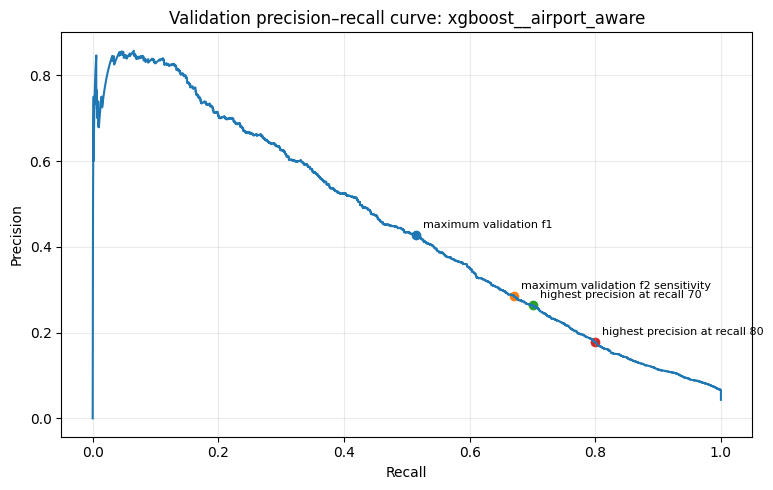

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(curve_table["recall"], curve_table["precision"])
for row in selected_thresholds.itertuples():
    ax.scatter(row.recall, row.precision)
    ax.annotate(
        row.rule.replace("_", " "),
        (row.recall, row.precision),
        xytext=(5, 5), textcoords="offset points", fontsize=8
    )
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"Validation precision–recall curve: {SELECTED_KEY}")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 15. Confusion matrices at meaningful thresholds

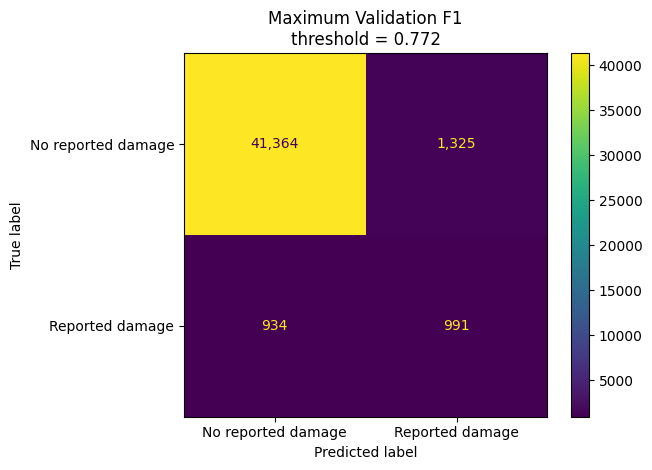

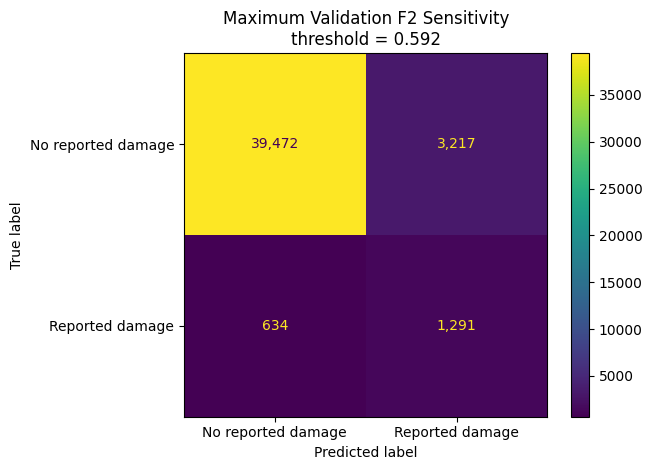

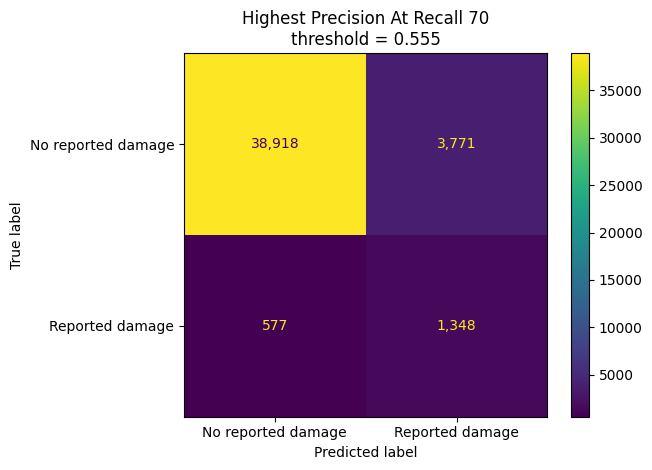

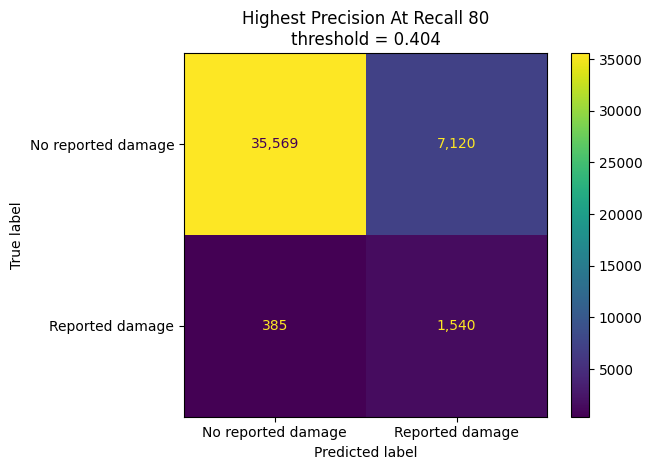

In [20]:
threshold_lookup = dict(zip(
    selected_thresholds["rule"], selected_thresholds["threshold"]
))
rules_to_plot = [
    "maximum_validation_f1",
    "maximum_validation_f2_sensitivity",
    "highest_precision_at_recall_70",
    "highest_precision_at_recall_80",
]

for rule in rules_to_plot:
    if rule not in threshold_lookup:
        continue
    threshold = threshold_lookup[rule]
    predictions = (selected_val_prob >= threshold).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_validation, predictions,
        labels=[0, 1],
        display_labels=["No reported damage", "Reported damage"],
        values_format=","
    )
    plt.title(f"{rule.replace('_', ' ').title()}\nthreshold = {threshold:.3f}")
    plt.tight_layout()
    plt.show()

### Confusion-matrix interpretation

At the maximum-F1 threshold, the model correctly identified 991 of the 1,925
reported-damage incidents and missed 934. It generated 1,325 false positives
among the 42,689 non-damage incidents.

At the maximum-F2 threshold, true positives increased to approximately 1,291
and false negatives fell to 634. This sensitivity gain required approximately
3,217 false positives.

At the 70% recall operating point, the model identified approximately 1,348
damage incidents and missed 577, while producing approximately 3,772 false
positives. At the 80% recall operating point, it identified 1,540 damage
incidents and missed 385, but false positives increased to approximately
7,121.

Thus, moving from the F1 threshold to the 80% recall threshold prevents about
549 additional missed-damage classifications, but introduces roughly 5,796
additional false alarms. No threshold can be recommended operationally until
the relative consequences of those two errors are defined.

## 16. Save uncalibrated candidate pipelines for Notebook 06

The fitted candidate pipelines are saved in `models/candidates/`. These are
intermediate model artifacts rather than the final project model.

Each artifact contains both the fitted preprocessing pipeline and the fitted
classifier. Notebook 06 will load these candidates, compare calibration
methods, and perform chronological and airport-held-out validation before
saving one canonical calibrated pipeline in `models/final/`.

In [21]:
candidate_manifest = []

for candidate_key, pipeline in fitted_candidates.items():
    artifact_path = MODEL_DIR / f"{candidate_key}_uncalibrated.joblib"
    joblib.dump(pipeline, artifact_path)
    candidate_manifest.append({
        "candidate": candidate_key,
        "path": str(artifact_path),
        "selected_for_primary_calibration": candidate_key == SELECTED_KEY,
        "file_size_mb": artifact_path.stat().st_size / 1024**2,
    })

manifest_df = pd.DataFrame(candidate_manifest)
manifest_df.to_csv(
    OUTPUT_DIR / "uncalibrated_candidate_manifest.csv", index=False
)
display(manifest_df.round(2))

,candidate,path,selected_for_primary_calibration,file_size_mb
0,logistic__extended_geographic,c:\Users\davis\Programing\MDA_programs\Capston...,False,0.01
1,random_forest__extended_geographic,c:\Users\davis\Programing\MDA_programs\Capston...,False,150.46
2,xgboost__extended_geographic,c:\Users\davis\Programing\MDA_programs\Capston...,False,2.14
3,logistic__airport_aware,c:\Users\davis\Programing\MDA_programs\Capston...,False,0.06
4,random_forest__airport_aware,c:\Users\davis\Programing\MDA_programs\Capston...,False,39.86
5,xgboost__airport_aware,c:\Users\davis\Programing\MDA_programs\Capston...,True,1.86


## 17. Demonstration export: transformed model-input sample

This sample shows what the selected pipeline actually passes to its estimator after fitting preprocessing on the 1990–2018 training period.

The complete transformed matrix is not exported because sparse one-hot encoding—especially for airports—can create thousands of columns and a very large file. Instead, the notebook exports:

1. a reproducible sample of transformed training rows,
2. every transformed feature name,
3. dimensions and missing-value checks.

This is sufficient to demonstrate that the estimator receives a numerical matrix with no NaN values.

In [22]:
selected_feature_set = selected_row["feature_set"]
selected_features = FEATURE_SETS[selected_feature_set]

sample_source = df.loc[train_mask, selected_features].sample(
    n=min(1000, int(train_mask.sum())),
    random_state=SEED
)

fitted_preprocessor = selected_pipeline.named_steps["preprocess"]
transformed_sample = fitted_preprocessor.transform(sample_source)
transformed_feature_names = fitted_preprocessor.get_feature_names_out()

if hasattr(transformed_sample, "toarray"):
    transformed_sample_array = transformed_sample.toarray()
else:
    transformed_sample_array = np.asarray(transformed_sample)

transformed_sample_df = pd.DataFrame(
    transformed_sample_array,
    columns=transformed_feature_names,
    index=sample_source.index
)
transformed_sample_df.insert(
    0, "INDEX_NR", df.loc[sample_source.index, "INDEX_NR"].to_numpy()
)

transformed_sample_path = (
    PROCESSED_DIR / "faa_strikes_training_matrix_sample.csv"
)
feature_manifest_path = (
    OUTPUT_DIR / "transformed_feature_manifest.csv"
)

transformed_sample_df.to_csv(transformed_sample_path, index=False)
pd.DataFrame({
    "feature_index": np.arange(len(transformed_feature_names)),
    "transformed_feature": transformed_feature_names
}).to_csv(feature_manifest_path, index=False)

transformed_info = pd.DataFrame([{
    "file": transformed_sample_path.name,
    "sample_rows": transformed_sample_df.shape[0],
    "columns_including_identifier": transformed_sample_df.shape[1],
    "transformed_model_features": len(transformed_feature_names),
    "file_size_mb": transformed_sample_path.stat().st_size / 1024**2,
    "nan_cells": int(transformed_sample_df.isna().sum().sum()),
    "purpose": "Demonstrate numerical input after training-fitted preprocessing"
}])
display(transformed_info.round(2))
display(transformed_sample_df.head())

assert transformed_sample_df.drop(columns="INDEX_NR").isna().sum().sum() == 0

,file,sample_rows,columns_including_identifier,transformed_model_features,file_size_mb,nan_cells,purpose
0,faa_strikes_training_matrix_sample.csv,1000,483,482,1.89,0,Demonstrate numerical input after training-fit...


,INDEX_NR,numeric__MONTH_SIN,numeric__MONTH_COS,numeric__NUM_ENGS,numeric__HEIGHT,numeric__SPEED,num_struck_ordinal__NUM_STRUCK,categorical__SEASON_Autumn,categorical__SEASON_Spring,categorical__SEASON_Summer,categorical__SEASON_Winter,categorical__WILDLIFE_TYPE_Bat,categorical__WILDLIFE_TYPE_Bird,categorical__WILDLIFE_TYPE_Other wildlife,categorical__WILDLIFE_TYPE_Reptile,categorical__WILDLIFE_TYPE_Terrestrial mammal,categorical__SIZE_Large,categorical__SIZE_Medium,categorical__SIZE_Not reported,categorical__SIZE_Small,categorical__AC_CLASS_A,categorical__AC_CLASS_B,categorical__AC_CLASS_Not reported,categorical__AC_CLASS_infrequent_sklearn,categorical__AC_MASS_GROUP_Heavy,categorical__AC_MASS_GROUP_Light,categorical__AC_MASS_GROUP_Medium,categorical__AC_MASS_GROUP_Unknown,categorical__TYPE_ENG_A,categorical__TYPE_ENG_B,categorical__TYPE_ENG_C,categorical__TYPE_ENG_D,categorical__TYPE_ENG_F,categorical__TYPE_ENG_Not reported,categorical__TYPE_ENG_infrequent_sklearn,categorical__WARNED_No,categorical__WARNED_Unknown,categorical__WARNED_Yes,categorical__PHASE_OF_FLIGHT_Approach,categorical__PHASE_OF_FLIGHT_Arrival,categorical__PHASE_OF_FLIGHT_Climb,categorical__PHASE_OF_FLIGHT_Departure,categorical__PHASE_OF_FLIGHT_Descent,categorical__PHASE_OF_FLIGHT_En Route,categorical__PHASE_OF_FLIGHT_Landing Roll,categorical__PHASE_OF_FLIGHT_Local,categorical__PHASE_OF_FLIGHT_Not reported,categorical__PHASE_OF_FLIGHT_Parked,categorical__PHASE_OF_FLIGHT_Take-off Run,categorical__PHASE_OF_FLIGHT_Taxi,categorical__TIME_OF_DAY_Dawn,categorical__TIME_OF_DAY_Day,categorical__TIME_OF_DAY_Dusk,categorical__TIME_OF_DAY_Night,categorical__TIME_OF_DAY_Not reported,categorical__SKY_No Cloud,categorical__SKY_Not reported,categorical__SKY_Overcast,categorical__SKY_Some Cloud,categorical__PRECIPITATION_Fog,"categorical__PRECIPITATION_Fog, Rain",categorical__PRECIPITATION_Not reported,categorical__PRECIPITATION_Rain,categorical__PRECIPITATION_Snow,categorical__PRECIPITATION_infrequent_sklearn,categorical__STATE_AK,categorical__STATE_AL,categorical__STATE_AR,categorical__STATE_AZ,categorical__STATE_BC,categorical__STATE_CA,categorical__STATE_CO,categorical__STATE_CT,categorical__STATE_DC,categorical__STATE_DE,...,categorical__AIRPORT_ID_KSFO,categorical__AIRPORT_ID_KSGF,categorical__AIRPORT_ID_KSGJ,categorical__AIRPORT_ID_KSHV,categorical__AIRPORT_ID_KSJC,categorical__AIRPORT_ID_KSLC,categorical__AIRPORT_ID_KSLE,categorical__AIRPORT_ID_KSMF,categorical__AIRPORT_ID_KSNA,categorical__AIRPORT_ID_KSPI,categorical__AIRPORT_ID_KSQL,categorical__AIRPORT_ID_KSRQ,categorical__AIRPORT_ID_KSTL,categorical__AIRPORT_ID_KSTP,categorical__AIRPORT_ID_KSTS,categorical__AIRPORT_ID_KSUS,categorical__AIRPORT_ID_KSUX,categorical__AIRPORT_ID_KSWF,categorical__AIRPORT_ID_KSYR,categorical__AIRPORT_ID_KTEB,categorical__AIRPORT_ID_KTKI,categorical__AIRPORT_ID_KTLH,categorical__AIRPORT_ID_KTMB,categorical__AIRPORT_ID_KTOL,categorical__AIRPORT_ID_KTPA,categorical__AIRPORT_ID_KTRI,categorical__AIRPORT_ID_KTTN,categorical__AIRPORT_ID_KTUL,categorical__AIRPORT_ID_KTUS,categorical__AIRPORT_ID_KTVC,categorical__AIRPORT_ID_KTWF,categorical__AIRPORT_ID_KTYR,categorical__AIRPORT_ID_KTYS,categorical__AIRPORT_ID_KUES,categorical__AIRPORT_ID_KUGN,categorical__AIRPORT_ID_KUNV,categorical__AIRPORT_ID_KVNY,categorical__AIRPORT_ID_KVQQ,categorical__AIRPORT_ID_KVRB,categorical__AIRPORT_ID_KXNA,categorical__AIRPORT_ID_KYIP,categorical__AIRPORT_ID_KYKM,categorical__AIRPORT_ID_LFPG,categorical__AIRPORT_ID_MMGL,categorical__AIRPORT_ID_MMMX,categorical__AIRPORT_ID_MMUN,categorical__AIRPORT_ID_MNMG,categorical__AIRPORT_ID_MPTO,categorical__AIRPORT_ID_MROC,categorical__AIRPORT_ID_MSLP,categorical__AIRPORT_ID_PAFA,categorical__AIRPORT_ID_PAJN,categorical__AIRPORT_ID_PANC,categorical__AIRPORT_ID_PASI,categorical__AIRPORT_ID_PGSN,categorical__AIRPORT_ID_PGUM,categorical__AIRPORT_ID_PHJH,categorical__AIRPORT_ID_PHJR,categorical__AIRPORT_ID_PHLI,categorical__AIRPORT_ID_PHMK,categorical__AIRPORT_ID_PHNL,categori

### Transformed-data interpretation

The selected airport-aware preprocessing pipeline converted the readable
feature set into 482 numerical model features. The demonstration export
contains 1,000 sampled training records and 483 columns, including `INDEX_NR`
for traceability. The model-input portion contains no remaining NaN values.

The increase from the original predictor count to 482 transformed features is
mainly caused by one-hot encoding of categorical variables, particularly
airport identifiers and other multi-level categories. This does not mean that
482 independent source variables were collected. Most transformed columns
are binary indicators derived from the original eligible predictors.

The sample also confirms that `NUM_STRUCK` enters the estimator as one ordered
feature rather than as an exact count. Its values represent increasing
reported ranges. The serialized pipeline, rather than this demonstration CSV,
remains the authoritative transformation because it stores the fitted
imputation, category, and encoding rules.

## 18. Output inventory and dataset-size evidence

In [23]:
output_inventory = []

for path, purpose in [
    (premodel_path, "Readable cleaned pre-model dataset"),
    (transformed_sample_path, "No-NaN transformed training sample"),
    (feature_manifest_path, "Complete transformed feature names"),
    (OUTPUT_DIR / "internal_tuning_results.csv", "Chronological tuning evidence"),
    (OUTPUT_DIR / "validation_model_comparison.csv", "Validation metrics"),
    (OUTPUT_DIR / "validation_probability_predictions.csv", "Probabilities for calibration"),
    (OUTPUT_DIR / "selected_model_thresholds.csv", "Threshold decision evidence"),
    (OUTPUT_DIR / "uncalibrated_candidate_manifest.csv", "Candidate model artifacts"),
]:
    if path.exists():
        output_inventory.append({
            "artifact": path.name,
            "rows": (
                sum(1 for _ in open(path, encoding="utf-8", errors="ignore")) - 1
                if path.suffix == ".csv" else np.nan
            ),
            "file_size_mb": path.stat().st_size / 1024**2,
            "purpose": purpose,
        })

output_inventory_df = pd.DataFrame(output_inventory)
output_inventory_df.to_csv(
    OUTPUT_DIR / "notebook05_output_inventory.csv", index=False
)
display(output_inventory_df.round(2))

,artifact,rows,file_size_mb,purpose
0,faa_strikes_binary_model_ready.csv,319107,55.84,Readable cleaned pre-model dataset
1,faa_strikes_training_matrix_sample.csv,1000,1.89,No-NaN transformed training sample
2,transformed_feature_manifest.csv,482,0.02,Complete transformed feature names
3,internal_tuning_results.csv,94,0.02,Chronological tuning evidence
4,validation_model_comparison.csv,7,0.00,Validation metrics
5,validation_probability_predictions.csv,44614,5.67,Probabilities for calibration
6,selected_model_thresholds.csv,4,0.00,Threshold decision evidence
7,uncalibrated_candidate_manifest.csv,6,0.00,Candidate model artifacts


### Artifact interpretation

The notebook exported a 319,107-row readable pre-model dataset with 25
columns and a file size of approximately 55.84 MB. This file preserves the
cleaned analytical representation and its visible missing values before
training-fitted preprocessing.

The transformed demonstration sample contains 1,000 rows, 482 model features,
and no missing cells. A separate feature manifest records all 482 transformed
feature names. Together, these outputs demonstrate both the human-readable
analytical dataset and the numerical representation supplied to the selected
estimator without requiring export of the complete dense transformed matrix.

The validation-probability file contains all 44,614 validation observations
and probabilities from each candidate. It is the principal handoff to
Notebook 06, where calibration methods can be compared without repeating the
80-minute tuning exercise.

## 19. Interpretation and hand-off to Notebook 06

### Main findings

The chronological validation period contained a reported-damage prevalence
of 4.31%. All fitted models substantially exceeded this no-skill PR-AUC
reference, demonstrating useful ability to rank higher- and lower-risk
reported strike scenarios. XGBoost produced the strongest discrimination,
with validation PR-AUC values of 0.4509 for the extended-geographic model and
0.4467 for the airport-aware model. Random Forest followed with PR-AUC values
of 0.4281 and 0.4356, while logistic regression achieved 0.3995 and 0.4052.

The best internal tuning PR-AUC was approximately 0.427. Validation PR-AUC did
not fall for the leading XGBoost candidates and was slightly higher in
2019–2021. This indicates that temporal movement into the official validation
period did not eliminate discrimination. It does not establish stable
long-term generalization, because the later 2022–2024 test period remains
locked and the damage prevalence changed substantially over time.

The airport-aware XGBoost candidate was selected for primary calibration. Its
PR-AUC was within 1% of the best validation result, while it achieved better
Brier score and log loss than extended-geographic XGBoost. The selection is
therefore based on a balance between discrimination and raw probability
quality rather than PR-AUC alone.

Airport identity did not create a consistent improvement across algorithms.
It modestly increased PR-AUC for logistic regression and Random Forest, but
slightly reduced XGBoost PR-AUC while improving its Brier score and log loss.
The contribution of `AIRPORT_ID` must therefore be tested under an
airport-held-out design before the airport-aware model can be accepted for
new locations.

At the maximum-F1 threshold of 0.7719, the selected model attained precision
of 0.4279, recall of 0.5148, and F1 of 0.4673. More recall-sensitive operating
points captured between approximately 67% and 80% of reported-damage cases,
but precision declined from 28.64% to 17.78%. These thresholds describe
classification trade-offs only. They are not yet suitable as operational
rules, and the uncalibrated probability values should not be interpreted
literally.

### Candidates carried forward

Notebook 06 should carry forward at least:

1. `xgboost__airport_aware` as the selected primary candidate;
2. `xgboost__extended_geographic` as the highest-PR-AUC candidate and the
   non-airport comparison;
3. `random_forest__extended_geographic` or
   `random_forest__airport_aware` because Random Forest achieved better raw
   Brier scores than XGBoost;
4. the best logistic-regression candidate as an interpretable benchmark.

Notebook 06 must compare raw and calibrated probabilities using calibration
curves, Brier score, and log loss. It must also evaluate future-year
performance, airport-held-out performance, rare-category behavior, and error
patterns before saving a canonical calibrated pipeline.

### Final-test protection

The 2022–2024 final test observations were not used for hyperparameter tuning,
candidate selection, threshold selection, or the results reported in this
notebook. They remain protected for the locked generalization assessment.

## 20. Limitations

- The target represents **reported aircraft damage conditional on a reported wildlife strike**.
- The analysis is observational and supports prediction and association, not causal claims.
- Reporting practices and field completeness changed over time.
- Airport identity can improve fit by representing persistent local patterns, but it can also encourage memorization and poor behavior for unseen airports.
- `NUM_STRUCK` contains ordered ranges rather than exact counts.
- Class weighting changes model fitting and may affect raw calibration; this is one reason Notebook 06 is mandatory.
- Validation threshold choices do not create an operational policy. A real deployment would need explicit costs for missed damage and false alarms.
- The transformed CSV is a demonstration sample, not a replacement for the serialized preprocessing pipeline.

## References used for evaluation choices

- Davis, J., & Goadrich, M. (2006). *The Relationship Between Precision-Recall and ROC Curves*. ICML.
- Saito, T., & Rehmsmeier, M. (2015). *The Precision-Recall Plot Is More Informative than the ROC Plot When Evaluating Binary Classifiers on Imbalanced Datasets*. PLOS ONE.
- Lipton, Z. C., Elkan, C., & Narayanaswamy, B. (2014). *Thresholding Classifiers to Maximize F1 Score*. arXiv:1402.1892 / ECML PKDD.
- Niculescu-Mizil, A., & Caruana, R. (2005). *Predicting Good Probabilities with Supervised Learning*. ICML.
- scikit-learn documentation: precision-recall curves, average precision, probability calibration, and model evaluation.
- XGBoost documentation: scikit-learn estimator interface and imbalanced binary classification parameters.

F1 is the primary threshold because the project has no defined cost ratio and seeks a balanced precision-recall operating point. F2 is presented only as a recall-emphasized sensitivity analysis. The 70% and 80% recall points make the trade-off visible without claiming that either level is inherently optimal.